In [3]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import math

# --- 1. CONFIGURATION DES MODULES S4 (Mélange des Semestres) ---
# Nous utilisons les 12 modules réels fournis par l'utilisateur
modules_s1 = ["DBA", "Python", "Optimisation", "Anglais", "ML", "Innovation"]
modules_s2 = ["Oracle", "DevOps", "AI", "Prolog", "BigData", "Soft Skills"]
all_modules = modules_s1 + modules_s2 # Fusion : 12 dimensions

# --- 2. DATASET S4 (SIMULÉ) ---
# Génération de 30 étudiants (observations) avec des notes (caractéristiques) entre 4 et 20
X_s4_master = np.random.randint(4, 21, size=(30, 12))

# --- 3. LOGIQUE DE LABELLISATION MULTI-ÉTATS (ID3) ---
# Objectif : Transformer les notes continues en classes discrètes (Y)
# 1 : Réussite Directe (Moyenne >= 12), Passage simple.
# 0 : Rattrapage (10 <= Moyenne < 12), Passage conditionnel.
# -1: Échec Critique (Moyenne < 10), Pas de passage.

def label_master_s4(notes):
    # Moyenne simple des notes sur les 12 modules
    moyenne_etudiant = np.mean(notes)

    if moyenne_etudiant >= 12:
        return 1
    elif 10 <= moyenne_etudiant < 12:
        return 0
    else:
        return -1

# Création du vecteur cible (Y) : Contient {-1, 0, 1}
y_s4_labels = np.array([label_master_s4(etudiant) for etudiant in X_s4_master])

In [4]:
# --- 1. FONCTION : ENTROPIE DE SHANNON (H(S)) ---
# Math From Scratch : Mesure le désordre ou l'incertitude dans un jeu de données.
# Formule : H(S) = -Σ p_i * log2(p_i)
# où p_i est la probabilité d'occurrence de la classe i.
def calcul_entropie(labels):
    n_observations = len(labels)
    # Gère le cas d'un nœud vide (l'entropie est nulle)
    if n_observations == 0: return 0

    # Compte les occurrences de chaque classe {-1, 0, 1}
    # Exemple : {1: 12, 0: 5, -1: 3}
    counts_classe = Counter(labels)

    entropie_val = 0
    # Boucle sur chaque classe trouvée
    for count in counts_classe.values():
        # p_i = (Nombre d'éléments de la classe i) / (Nombre total d'éléments)
        probabilite_pi = count / n_observations

        # log2(0) est indéfini. On s'assure que la probabilité n'est pas nulle.
        if probabilite_pi > 0:
            # -p_i * log2(p_i)
            entropie_val -= probabilite_pi * math.log2(probabilite_pi)

    # L'entropie est maximale (proche de 1.58 pour 3 classes) si le mélange est parfait
    # Elle est minimale (0) si tous les éléments appartiennent à la même classe (pureté).
    return entropie_val

# --- 2. FONCTION : GAIN D'INFORMATION (IG) ---
# Math From Scratch : Calcule la réduction de l'entropie apportée par une division.
# Formule : IG(S, A) = H(S) - Σ (|Sv|/|S|) * H(Sv)
# où H(S) est l'entropie initiale, Sv est le sous-ensemble créé par la division v.
def executer_analyse_id3_s4(X, y, noms_modules):
    # Entropie de base avant toute division
    entropie_initiale = calcul_entropie(y)

    gains_par_module = []

    print(f"--- ANALYSE ID3 MASTER S4 ---")
    print(f"Entropie initiale H(Master): {round(entropie_initiale, 4)}\n")
    print("GAINS PAR MODULE (HIÉRARCHIE ID3)")

    # Boucle sur les 12 modules pour trouver le meilleur split
    for i, name in enumerate(noms_modules):
        # ID3 Standard : Split binaire sur le seuil critique académique (10/20)
        # Groupe G : Étudiants en difficulté (< 10)
        # Groupe D : Étudiants ayant validé (>= 10)
        mask = X[:, i] < 10
        y_groupe_g = y[mask]
        y_groupe_d = y[~mask]

        # Probabilité pondérée des sous-groupes (P(G) et P(D))
        pond_g = len(y_groupe_g) / len(y)
        pond_d = len(y_groupe_d) / len(y)

        # Σ P(v) * H(Sv) : Somme de l'entropie pondérée des enfants
        entropie_ponderee_enfants = (pond_g * calcul_entropie(y_groupe_g) +
                                     pond_d * calcul_entropie(y_groupe_d))

        # Gain = H(Initial) - H(Pondérée Enfants)
        # Plus le gain est grand, plus la division a "purgé" le désordre.
        gain = entropie_initiale - entropie_ponderee_enfants
        gains_par_module.append(gain)

        print(f"{name:15} : Gain IG = {round(gain, 4)}")

    # ID3 choisit la caractéristique avec le Gain d'Information MAXIMUM
    best_module_idx = np.argmax(gains_par_module)
    print(f"\n MEILLEUR MODULE GLOBAL (RACINE ID3) : {noms_modules[best_module_idx]}")

    # Retourne l'index du meilleur module pour la visualisation
    return best_module_idx

# Exécution de l'analyse mathématique
# Cette valeur déterminera quel module sera affiché en jaune dans le graphe.
idx_meilleur_module = executer_analyse_id3_s4(X_s4_master, y_s4_labels, all_modules)

--- ANALYSE ID3 MASTER S4 ---
Entropie initiale H(Master): 1.4591

GAINS PAR MODULE (HIÉRARCHIE ID3)
DBA             : Gain IG = 0.0647
Python          : Gain IG = 0.2451
Optimisation    : Gain IG = 0.0201
Anglais         : Gain IG = 0.0166
ML              : Gain IG = 0.2891
Innovation      : Gain IG = 0.1029
Oracle          : Gain IG = 0.0042
DevOps          : Gain IG = 0.0876
AI              : Gain IG = 0.0299
Prolog          : Gain IG = 0.1345
BigData         : Gain IG = 0.2334
Soft Skills     : Gain IG = 0.0449

 MEILLEUR MODULE GLOBAL (RACINE ID3) : ML


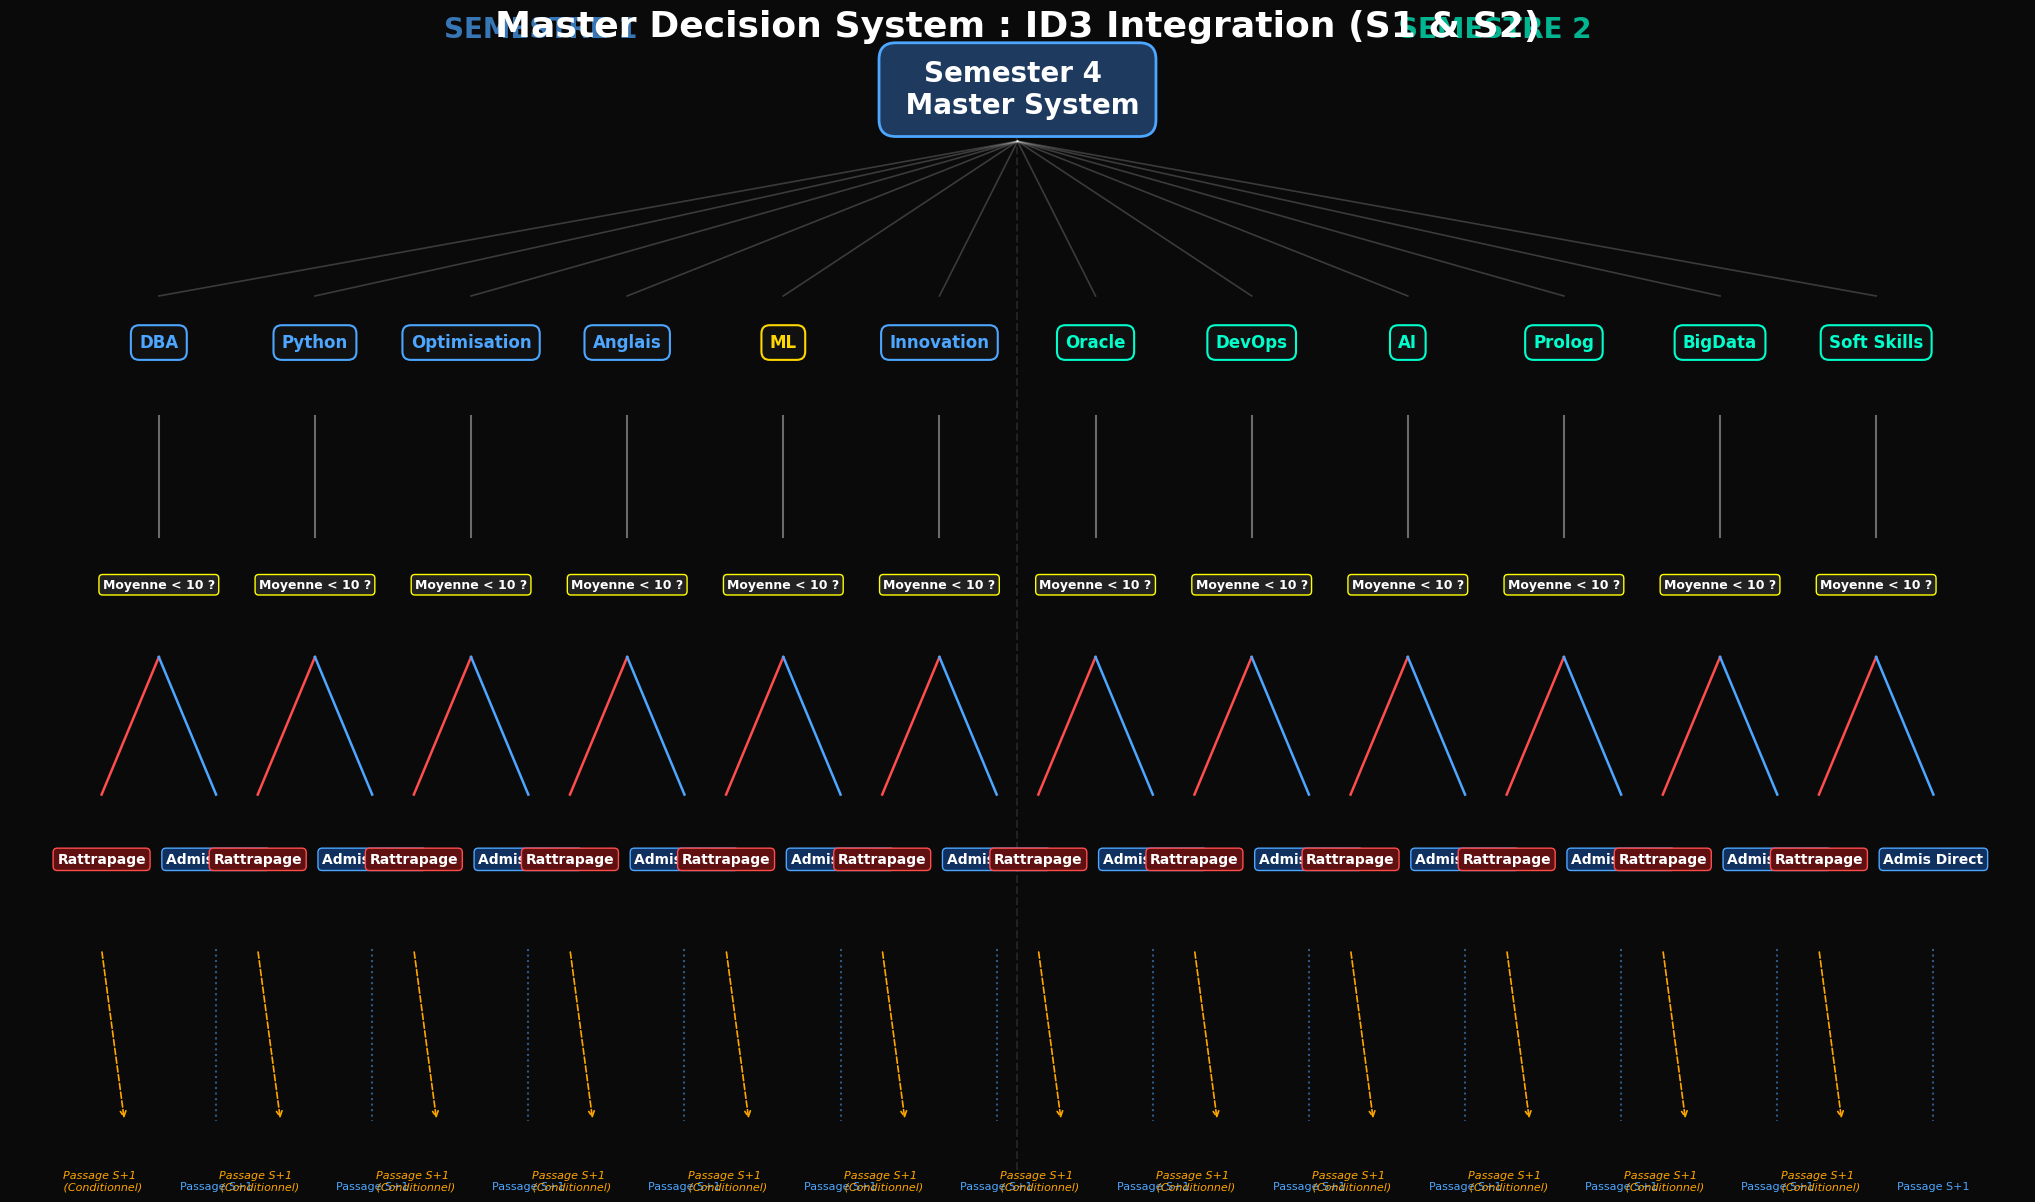

In [5]:
def visualize_master_tree_improved(best_module_idx):
    # Création d'une figure très large pour ne pas étouffer les branches
    fig, ax = plt.subplots(figsize=(26, 14))

    # Thème "Mode Sombre" pour faire ressortir les couleurs néon
    fig.patch.set_facecolor("#0A0A0A")  # Fond global
    ax.set_facecolor("#0A0A0A")         # Fond de la zone de tracé
    ax.axis('off')                      # Désactive les axes X/Y standard

    # Titre Principal
    plt.title("Master Decision System : ID3 Integration (S1 & S2)", color='white', fontsize=26, fontweight='bold', pad=40)

    # --- 1. SÉPARATION VISUELLE S1 / S2 ---
    # Ligne verticale de séparation pour l'année
    ax.axvline(x=0.5, color='white', linestyle='--', alpha=0.1)
    # Titres des semestres
    ax.text(0.25, 0.98, "SEMESTRE 1", color='#4DA6FF', fontsize=20, ha='center', fontweight='bold', alpha=0.7)
    ax.text(0.75, 0.98, "SEMESTRE 2", color='#00FFCC', fontsize=20, ha='center', fontweight='bold', alpha=0.7)

    # Racine du Système (Global Master Decision)
    ax.text(0.5, 0.95, "Semester 4 \n Master System", ha='center', va='center', fontsize=20, color='white', fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.6", facecolor="#1E3A5F", edgecolor="#4DA6FF", linewidth=2))

    # --- 2. DISTRIBUTION DES MODULES (12 DIMENSIONS) ---
    # Positionnement horizontal uniforme des 12 branches
    pos_modules = np.linspace(0.05, 0.95, len(all_modules))

    for i, mod_name in enumerate(all_modules):
        x = pos_modules[i]

        # Code Couleur : S1 (Bleu), S2 (Cyan), Meilleur Module (Jaune)
        is_best = (i == best_module_idx)
        is_s1 = i < 6
        color_theme = "#FFD700" if is_best else ("#4DA6FF" if is_s1 else "#00FFCC")

        # Branche de connexion depuis la racine vers le module
        ax.plot([0.5, x], [0.92, 0.83], color='white', linewidth=1.2, alpha=0.2)

        # Noeud du Module (Stylisé)
        ax.text(x, 0.80, mod_name, ha='center', fontsize=12, fontweight='bold', color=color_theme,
                bbox=dict(facecolor='#111', edgecolor=color_theme, boxstyle='round,pad=0.5', linewidth=1.5))

        # --- 3. LOGIQUE DE DÉCISION (HYBRIDE S1/S2) ---
        # Ligne verticale vers le test de note
        ax.plot([x, x], [0.76, 0.69], color='white', alpha=0.4)
        # Nœud de test principal : Seuil académique
        ax.text(x, 0.66, "Moyenne < 10 ?", ha='center', fontsize=9, color='white', fontweight='bold',
                bbox=dict(boxstyle="round", facecolor='#222', edgecolor='yellow'))

        # Positions pour les sous-branches Échec/Réussite
        xl, xr = x-0.03, x+0.03
        y_branch_start, y_leaf_center = 0.62, 0.50

        # --- BRANCHE ROUGE : FLUX DE RATTRAPAGE ---
        # Branche descendant vers l'échec/rattrapage (Rouge vif)
        ax.plot([x, xl], [y_branch_start, y_leaf_center+0.04], color='#FF4D4D', linewidth=1.8)
        # Nœud "Rattrapage" (Rouge foncé)
        ax.text(xl, y_leaf_center, "Rattrapage", ha='center', color='white', size=10, fontweight='bold',
                bbox=dict(boxstyle="round", facecolor='#601010', edgecolor='#FF4D4D'))

        # Connexion vers le futur : Passage conditionnel au S+1
        # Flèche orange discontinue indiquant un flux dépendant de la réussite du rattrapage
        ax.annotate('', xy=(xl+0.012, 0.35), xytext=(xl, 0.45),
                    arrowprops=dict(arrowstyle='->', color='orange', linestyle='--', linewidth=1.2))
        # Texte de passage final
        ax.text(xl, 0.31, "Passage S+1 \n (Conditionnel)", ha='center', color='orange', size=8, style='italic')

        # --- BRANCHE BLEUE : FLUX DE RÉUSSITE DIRECTE ---
        # Branche descendant vers l'admissibilité directe (Bleu néon)
        ax.plot([x, xr], [y_branch_start, y_leaf_center+0.04], color='#4DA6FF', linewidth=1.8)
        # Nœud "Admis Direct" (Bleu foncé)
        ax.text(xr, y_leaf_center, "Admis Direct", ha='center', color='white', size=10, fontweight='bold',
                bbox=dict(boxstyle="round", facecolor='#103060', edgecolor='#4DA6FF'))

        # Connexion finale : Passage validé
        # Ligne discontinue bleu clair pour indiquer le flux validé
        ax.plot([xr, xr], [0.45, 0.35], color='#4DA6FF', alpha=0.5, linestyle=':')
        ax.text(xr, 0.31, "Passage S+1", ha='center', color='#4DA6FF', size=8)

    plt.show()

# --- EXÉCUTION DE LA VISUALISATION AMÉLIORÉE ---
visualize_master_tree_improved(idx_meilleur_module)